In [3]:
import os
import numpy as np
# from osgeo import gdal, osr
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.basemap import Basemap
from pyhdf.SD import SD, SDC

C:\Users\14390\AppData\Local\Temp\ipykernel_79640\395267084.py:70: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m.pcolormesh(longitude, latitude, data0, latlon=True)


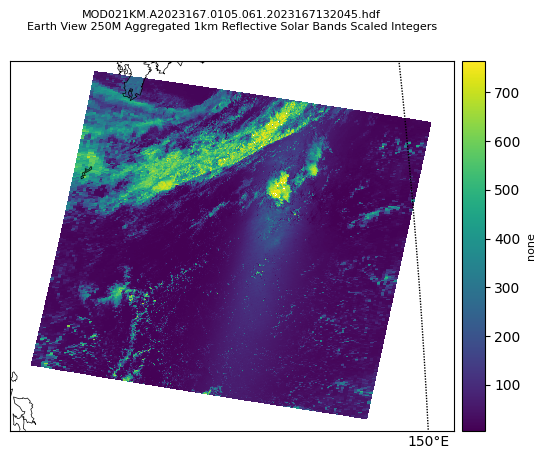

In [4]:
# 读取文件，用pyhdf读取遥感图像数据
FILE_NAME = 'Modis/MOD021KM.A2023216.0140.061.2023216131913.hdf'
FILE_NAME = 'Modis/MOD021KM.A2023167.0105.061.2023167132045.hdf'

DATAFIELD_NAME = 'EV_250_Aggr1km_RefSB'

hdf = SD(FILE_NAME, SDC.READ)

attrs = hdf.attributes(full=1)
nsa = attrs["Number of Scans"]
number_of_Scans = nsa[0]

# 提取近红外波段
data2D = hdf.select(DATAFIELD_NAME)
data = data2D[1,:,:].astype(np.double)

# 获取辐射校正所需的数据（辐射校正消除仪器本身的误差）
lat = hdf.select('Latitude')
latitude = lat[:,:]
lon = hdf.select('Longitude')
longitude = lon[:,:]

attrs=lat.attributes(full=1)
fna = attrs["frame_numbers"]
frame_numbers = fna[0][0]
lna = attrs["line_numbers"]
line_numbers = lna[0][0]

attrs = data2D.attributes(full=1)
lna=attrs["long_name"]
long_name = lna[0]
aoa=attrs["radiance_offsets"]
add_offset = aoa[0][0]
sfa=attrs["radiance_scales"]
scale_factor = sfa[0][0]
fva=attrs["_FillValue"]
_FillValue = fva[0]
vra=attrs["valid_range"]
valid_min = vra[0][0]
valid_max = vra[0][1]
ua=attrs["units"]
units = ua[0]

invalid = np.logical_or(data > valid_max,
data < valid_min)
invalid = np.logical_or(invalid, data == _FillValue)
data[invalid] = np.nan
data = (data - add_offset) * scale_factor
data = np.ma.masked_array(data, np.isnan(data))

# 获取经纬度中心
lat_m = np.nanmean(latitude)
lon_m = np.nanmean(longitude)

m = Basemap(projection='laea', resolution='l', lat_ts=65,
lat_0=lat_m, lon_0=lon_m,
width=3000000, height=2500000)
m.drawcoastlines(linewidth=0.5)
m.drawparallels(np.arange(50., 91., 10.), labels=[1, 0, 0, 0])
m.drawmeridians(np.arange(-180, 181., 30), labels=[0, 0, 0, 1])

data0 = data[:number_of_Scans*2,:271]
for i in range(0,number_of_Scans*2):
    for j in range(0,271):
        newi = i*5 + int(line_numbers)
        newj = j*5 + int(frame_numbers)
        # print(newi,newj)
        data0[i,j] = data[newi,newj]

m.pcolormesh(longitude, latitude, data0, latlon=True)
cb=m.colorbar()
cb.set_label(units, fontsize=8)

basename = os.path.basename(FILE_NAME)

plt.title('{0}\n{1}\n{2}\n{3}'.format(basename,
long_name[0:81],
long_name[81:158],
long_name[158:]),
fontsize=8)
fig = plt.gcf()
pngfile = "Output/{0}.py.png".format(basename)
fig.savefig(pngfile)

C:\Users\14390\AppData\Local\Temp\ipykernel_79640\2144607794.py:29: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m.pcolormesh(longitude, latitude, ndvi0, latlon=True, cmap='gray', vmin=-1, vmax=1)


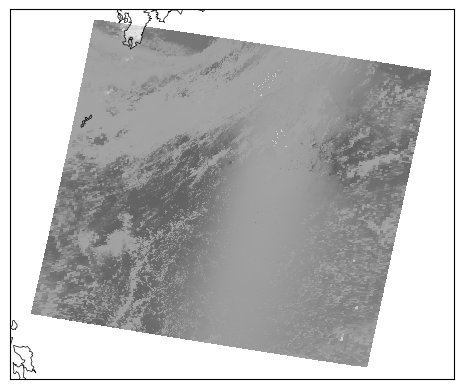

In [5]:
# 读取红光波段的数据
red_band = hdf.select('EV_250_Aggr1km_RefSB')  # MODIS红光波段1的数据字段
red_data = red_band[0,:,:].astype(np.double)

# 读取近红外波段的数据
nir_band = hdf.select('EV_250_Aggr1km_RefSB')  # MODIS近红外波段2的数据字段
nir_data = nir_band[1,:,:].astype(np.double)

# 计算NDVI
ndvi = (nir_data - red_data) / (nir_data + red_data)

# 掩膜无效值
ndvi = np.ma.masked_where(np.isnan(ndvi), ndvi)

# 使用Basemap绘制NDVI
m = Basemap(projection='laea', resolution='l', lat_ts=65,
            lat_0=lat_m, lon_0=lon_m,
            width=3000000, height=2500000)
m.drawcoastlines(linewidth=0.5)

ndvi0 = ndvi[:number_of_Scans*2,:271]
for i in range(0,number_of_Scans*2):
	for j in range(0,271):
		newi = i*5 + int(line_numbers)
		newj = j*5 + int(frame_numbers)
		ndvi0[i,j] = ndvi[newi,newj]

# 绘制NDVI
m.pcolormesh(longitude, latitude, ndvi0, latlon=True, cmap='gray', vmin=-1, vmax=1)

# 保存结果
pngfile = "Output/NDVI_Map.png"
plt.savefig(pngfile, dpi=300)

# 显示图像
plt.show()

C:\Users\14390\AppData\Local\Temp\ipykernel_79640\3019554653.py:32: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m.pcolormesh(longitude, latitude, RVI0, latlon=True, cmap='RdYlGn', vmin=-1, vmax=1)


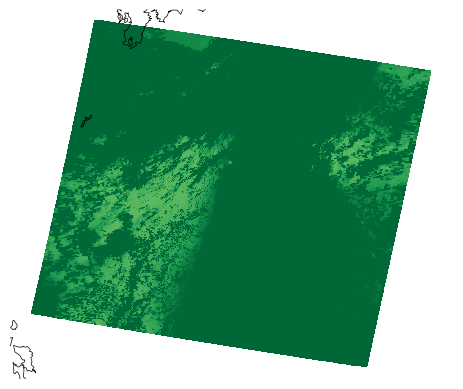

In [6]:
## RVI 比值植被指数 Ratio Vegetation Index

# 读取红光波段的数据
red_band = hdf.select('EV_250_Aggr1km_RefSB')  # MODIS红光波段1的数据字段
red_data = red_band[0,:,:].astype(np.double)

# 读取近红外波段的数据
nir_band = hdf.select('EV_250_Aggr1km_RefSB')  # MODIS近红外波段2的数据字段
nir_data = nir_band[1,:,:].astype(np.double)

# 计算NDVI
RVI = (nir_data) / (red_data)

# 掩膜无效值
RVI = np.ma.masked_where(np.isnan(RVI), RVI)

# 使用Basemap绘制NDVI
m = Basemap(projection='laea', resolution='l', lat_ts=65,
            lat_0=lat_m, lon_0=lon_m,
            width=3000000, height=2500000)
m.drawcoastlines(linewidth=0.5)

RVI0 = RVI[:number_of_Scans*2,:271]
for i in range(0,number_of_Scans*2):
	for j in range(0,271):
		newi = i*5 + int(line_numbers)
		newj = j*5 + int(frame_numbers)
		RVI0[i,j] = RVI[newi,newj]

# 绘制NDVI
# m.pcolormesh(longitude, latitude, RVI0, latlon=True, cmap='gray', vmin=-1, vmax=1)
m.pcolormesh(longitude, latitude, RVI0, latlon=True, cmap='RdYlGn', vmin=-1, vmax=1)


# 获取当前的Axes对象，并隐藏边框
ax = plt.gca()  # 获取当前的Axes对象
for spine in ax.spines.values():
    spine.set_visible(False)

# 可选：如果你不想要坐标轴上的刻度，也可以移除它们
ax.set_xticks([])
ax.set_yticks([])


# 保存结果
pngfile = "Output/NDVI_Map.png"
plt.savefig(pngfile, dpi=300, bbox_inches='tight', pad_inches=0)

# 显示图像
plt.show()